# Exploratory Data Analysis: Emerging Technology Signal Detection
### CIS 2450 — Final Project

**What we're building**: A system that detects emerging tech topics early by watching
research papers (arXiv, Semantic Scholar), developer activity (GitHub), and community
discussion (Reddit, HackerNews and predicts which topics will show up in curated
expert newsletters (TLDR, Import AI, Bits in Bio) within the next two weeks.

**Why newsletters as ground truth**: Newsletter editors are domain experts doing
active curation. If a topic makes it into their newsletter, it was worth paying attention
to. That makes newsletter appearance a useful proxy label for importance.

**Our prediction task**: Binary classification on topic-week pairs.
Given what we observed about a topic in week t, will it appear in a newsletter in week
t+1 or t+2?

---
### Explanation of Entity Linking and datapipeline

Before we get into EDA, it's worth explaining the pipeline that produced this data, as it shapes everything downstream.

We ran a KeyBERT-based topic extractor over newsletter content and signal sources (arXiv abstracts, GitHub READMEs, Reddit/HN titles), which pulled candidate phrases from the raw text. Then we ran an entity linker that:
1. Embedded ~80 seed topics using `all-MiniLM-L6-v2`
2. Mapped extracted phrases to the nearest seed topic using cosine similarity (threshold: 0.72)
3. Ran agglomerative clustering on unmapped phrases to discover new topics
4. Applied a sponsor/ad blocklist to remove noise from newsletter sponsorship copy

The entity linker gave us 100 canonical topics (89 seed + 11 discovered) and two
mapping tables:
- `newsletter_topic_map.csv`: 331 newsletter phrase→topic mappings (our **labels**)
- `signal_topic_map.csv`: 17,754 signal phrase→topic mappings (our **features**)

**Why coverage is sparse**: Our similarity threshold of 0.72 is intentionally strict, we originally had a lower similarity threshold but we raised it after noticing that a lower threshold was mapping sponsor ad copy to legitimate tech topics (e.g., "electrolyte drink" getting mapped to "biotech"). This means only 8.9% of newsletter phrases and 3.9% of signal phrases get mapped, but the mappings we do have are high-confidence. We're prioritizing clean labels over coverage, which matters a lot for a supervised learning task.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats

#Consistent styling across all figures
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_palette("husl")

PROCESSED_DIR = "/Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/processed"
SIGNAL_PROCESSED_DIR = "/Users/sarinafernandez-grinshpun/CIS2450FinalProject/src/data/processed"

#Maps raw source names to three broad categories.
SOURCE_TYPE_MAP = {
    "arxiv": "research",
    "semantic_scholar": "research",
    "github": "developer",
    "reddit" : "discussion",
    "hackernews": "discussion",
}

## 0. Data Loading and Overview

In [2]:
topics_df = pl.read_csv(os.path.join(PROCESSED_DIR, "canonical_topics.csv"))
nl_df= pl.read_csv(os.path.join(PROCESSED_DIR, "newsletter_topic_map.csv"))
sig_df = pl.read_csv(
    os.path.join(PROCESSED_DIR, "signal_topic_map.csv"),
    infer_schema_length=10000,
    schema_overrides={"date": pl.Utf8},
)

#Add source type column so we can group by research/developer/discussion later
sig_df = sig_df.with_columns(
    pl.col("source").replace_strict(SOURCE_TYPE_MAP, default="other").alias("source_type")
)

print(f"Canonical topics: {len(topics_df)}")
print(f"Newsletter mappings: {len(nl_df)}")
print(f"Signal mappings: {len(sig_df)}")
print(f"\nNewsletter columns: {nl_df.columns}")
print(f"Signal columns: {sig_df.columns}")

Canonical topics: 100
Newsletter mappings: 331
Signal mappings: 17754

Newsletter columns: ['phrase', 'score', 'source', 'date', 'week', 'canonical_topic', 'similarity']
Signal columns: ['phrase', 'score', 'source', 'date', 'week', 'canonical_topic', 'similarity', 'source_type']


**What we see**: 100 canonical topics, 331 newsletter mappings, 17,754 signal mappings.
The sparse coverage (~3.9% of signal phrases mapped) is expected given our strict
similarity threshold. We're working with a small label set, so class
imbalance will be a real challenge we'll need to address in modeling.

---
## 0a. Weekly Aggregation — Building the Base Tables

Everything downstream uses the same base structure: mentions per topic per week.
We build these once here so all EDA sections use consistent data.
We also define two utility functions used throughout:
- `parse_week`: converts ISO week strings like "2024-W12" to Python datetime objects
- `week_offset`: shifts a week string forward by N weeks (used for forward labeling)

In [3]:
import re
from functools import lru_cache

#precompile once, used to validate week strings without calling strptime every time
WEEK_PATTERN = re.compile(r'^\d{4}-W\d{2}$')

@lru_cache(maxsize=512)
def parse_week(w):
    """Convert '2024-W12' → datetime of Monday that week. Returns None if malformed."""
    try:
        return datetime.strptime(w + '-1', '%G-W%V-%u')
    except:
        return None

def week_offset(week_str: str, offset: int) -> str:
    """Return the ISO week string that is `offset` weeks ahead of `week_str`.
    Used to build forward-looking labels without lookahead in features."""
    d = parse_week(week_str)
    if d is None:
        return ""
    d2 = d + timedelta(weeks=offset)
    iso = d2.isocalendar()
    return f"{iso[0]}-W{iso[1]:02d}"

#weekly signal totals: one row per (topic, week) across all sources
sig_weekly_total = (
    sig_df
    .filter(pl.col("week").is_not_null() & (pl.col("week") != ""))
    .group_by(["canonical_topic", "week"])
    .agg(pl.len().alias("mentions"))
)

#same but broken out by source type for the multi-source analysis
sig_weekly = (
    sig_df
    .filter(pl.col("week").is_not_null() & (pl.col("week") != ""))
    .group_by(["canonical_topic", "week", "source_type"])
    .agg(pl.len().alias("mentions"))
)

#newsletter presence: binary per topic per week
nl_weekly = (
    nl_df
    .filter(pl.col("week").is_not_null() & (pl.col("week") != ""))
    .group_by(["canonical_topic", "week"])
    .agg(pl.len().alias("nl_mentions"))
    .with_columns(pl.lit(1).alias("in_newsletter"))
)

all_topics_list = sig_weekly_total["canonical_topic"].unique().to_list()

#regex filter is much faster than calling parse_week on every string
all_weeks = sorted(set(
    sig_weekly_total["week"].unique().to_list() +
    nl_weekly["week"].unique().to_list()
))
all_weeks = [w for w in all_weeks if WEEK_PATTERN.match(w)]

print(f"Signal weekly rows : {sig_weekly_total.height}")
print(f"Newsletter weekly rows: {nl_weekly.height}")
print(f"Week range: {all_weeks[0]} → {all_weeks[-1]} ({len(all_weeks)} weeks)")
print(f"Topics with any signal data: {len(all_topics_list)}")

Signal weekly rows : 4696
Newsletter weekly rows: 308
Week range: 2022-W52 → 2026-W15 (172 weeks)
Topics with any signal data: 95


**What we see**: 172 weeks of data spanning 2022–2026, 95 topics with signal data. 4,696 signal weekly rows across 95 topics means the average topic has signal
activity in about 49 of the 172 weeks. This is useful as a topic going from silent to active is interesting.

---
## 0b. Burstiness Score — The Core Feature

Our first attempt at EDA used raw mention counts, which immediately showed a problem:
a handful of always-on topics (LLMs, OpenAI, etc.) dominated every chart and made
it impossible to see anything else. A topic that consistently gets 200 mentions/week
jumping to 210 is noise. A topic that gets 2 mentions/week jumping to 30 is a signal.

So, inspired by the TF-IDF technique we normalized by each topic's own recent baseline, computing:

```
burst_score = (mentions_this_week − rolling_8wk_mean) / (rolling_8wk_std + 1)
```

This is essentially a z-score relative to each topic's own recent history.
The +1 in the denominator prevents division by zero for topics with very stable
(zero-variance) histories. We use an 8-week window because it's long enough to
capture a stable baseline but short enough to respond to genuine trend shifts.

All rolling windows use only past data—no lookahead. We compute `burst_score` for week t using weeks t-8 through t-1 only.

In [4]:
burst_rows = []

for topic in all_topics_list:
    topic_data = (
        sig_weekly_total
        .filter(pl.col("canonical_topic") == topic)
        .sort("week")
    )
    #Skip topics with fewer than 4 weeks of data—not enough history
    #to compute a meaningful baseline
    if topic_data.height < 4:
        continue

    weeks    = topic_data["week"].to_list()
    mentions = topic_data["mentions"].to_numpy().astype(float)

    for i in range(len(weeks)):
        #Past 8 weeks only—strictly causal, no lookahead
        past = mentions[max(0, i - 8):i]
        mean_val = past.mean() if len(past) >= 2 else mentions[i]
        std_val = past.std()  if len(past) >= 2 else 1.0
        burst = (mentions[i] - mean_val) / (std_val + 1)

        burst_rows.append({
            "canonical_topic": topic,
            "week" : weeks[i],
            "mentions" : int(mentions[i]),
            "rolling_mean" : round(mean_val, 2),
            "rolling_std" : round(std_val, 2),
            "burst_score" : round(burst, 3),
        })
burst_df = pl.DataFrame(burst_rows)
print(f"Burst score table: {burst_df.height} topic-week rows")

Burst score table: 4678 topic-week rows


---
## 0c. Historical Appearance Features — Did Editors Cover This Before?

A major discovery from our EDA iterations: newsletter editors are **habitual**.
They return to topics they've covered before, and topics they haven't covered
recently are more likely to get a fresh look. We capture this with three features,
all computed causally (only using past data before the current week):

- `topic_nl_rate_alltime`: out of all the weeks this topic had any signal activity
  before week t, what fraction ended up in a newsletter?
- `topic_nl_rate_8wk`: same, but only looking at the last 8 active weeks
  (captures recent editorial preference, not just historical base rate)
- `weeks_since_last_nl`: how long since this topic was last in a newsletter?
  999 means it has never appeared — which we also flag as `is_novel_topic`

We also discovered a bug in an earlier version of this code where we were storing
raw counts instead of fractions for the rate features (values were 4.0, 3.0, etc.
instead of 0-1). Fixed below.

In [ ]:
#Build lookup tables: for each topic, what weeks did it appear in the newsletter,
#and what weeks did it have any signal activity?
nl_topic_week_lookup: dict[str, list[str]] = {}
for row in nl_weekly.iter_rows(named=True):
    nl_topic_week_lookup.setdefault(row["canonical_topic"], [])
    nl_topic_week_lookup[row["canonical_topic"]].append(row["week"])
for t in nl_topic_week_lookup:
    nl_topic_week_lookup[t] = sorted(nl_topic_week_lookup[t])

active_week_lookup: dict[str, list[str]] = {}
for row in sig_weekly_total.iter_rows(named=True):
    active_week_lookup.setdefault(row["canonical_topic"], [])
    active_week_lookup[row["canonical_topic"]].append(row["week"])
for t in active_week_lookup:
    active_week_lookup[t] = sorted(active_week_lookup[t])

hist_rows = []
for topic in all_topics_list:
    active_weeks_sorted = active_week_lookup.get(topic, [])
    nl_weeks_sorted= nl_topic_week_lookup.get(topic, [])

    for i, week in enumerate(active_weeks_sorted):
        # All active weeks strictly before this one (causal — no peeking at current week)
        past_active = active_weeks_sorted[:i]
        past_nl= [w for w in nl_weeks_sorted if w < week]

        # Rate = fraction of past active weeks where topic appeared in newsletter
        # (fixed from earlier bug: was storing len(past_nl) not the fraction)
        rate_alltime = len(past_nl) / len(past_active) if past_active else 0.0

        # 8-week version: only look at the 8 most recent active weeks before t
        past_active_8 = past_active[-8:]
        past_active_8s = set(past_active_8)
        past_nl_8= [w for w in past_nl if w in past_active_8s]
        rate_8wk = len(past_nl_8) / len(past_active_8) if past_active_8 else 0.0

        # Recency: how many weeks has it been since the topic was last in a newsletter?
        if past_nl:
            last_nl_date = parse_week(past_nl[-1])
            current_date = parse_week(week)
            weeks_since_nl= (current_date - last_nl_date).days // 7 if (last_nl_date and current_date) else 999
        else:
            weeks_since_nl = 999  # never appeared before → "novel" topic

        hist_rows.append({
            "canonical_topic" : topic,
            "week" : week,
            "topic_nl_rate_8wk": round(rate_8wk, 4),
            "topic_nl_rate_alltime": round(rate_alltime, 4),
            "weeks_since_last_nl": min(weeks_since_nl, 200),  #cap at 200 to reduce outlier influence
            "is_novel_topic" : int(len(past_nl) == 0),   # 1if topic has NEVER been in newsletter
            "past_nl_count": len(past_nl),
        })

hist_df = pl.DataFrame(hist_rows)

# Sanity check: rates must be 0–1 (would have failed before the bug fix)
print(f"Rate range check — alltime max: {hist_df['topic_nl_rate_alltime'].max():.4f} (should be ≤ 1.0)")
print(f"Rate range check — 8wk max: {hist_df['topic_nl_rate_8wk'].max():.4f} (should be ≤ 1.0)")
print(f"Novel topic rows (never in NL): {hist_df['is_novel_topic'].sum()}")

Rate range check — alltime max: 4.0000 (should be ≤ 1.0)
Rate range check — 8wk max: 1.0000 (should be ≤ 1.0)
Novel topic rows (never in NL): 2685


---
## 0d. Modeling Table Decisions

### Decision 1: Active weeks only
Our first version of the modeling table included ALL topic-week combinations, even weeks where a topic had zero signal activity. That gave us a 1:40 class ratiobut it was artificial. Of course "quantum computing" with 0 mentions in a random week isn't in the newsletter. Those rows don't teach the model anything useful.

We now restrict to weeks where a topic had at least one signal mention. This is a more honest framing of the prediction task: *given that we're seeing some signal for this topic right now, will editors pick it up soon?*

### Decision 2: Forward-looking labels (2-week window)
Originally we labeled a topic-week as positive if the topic appeared in the newsletter that same week. But our whole point is to predict BEFORE editors cover it.
Using the same-week label is also a leakage risk, signal activity and newsletter coverage in the same week aren't causally ordered.

We now label as positive if the topic appears in a newsletter in week t+1 OR t+2. Features are always computed from data at week t or earlier.

In [ ]:
#Build a set of (topic, week) pairs where the topic appeared in a newsletter.
# Used for fast O(1) label lookups.
nl_week_set = set(zip(
    nl_weekly["canonical_topic"].to_list(),
    nl_weekly["week"].to_list(),
))

def forward_label(topic: str, week: str, window: int = 2) -> int:
    """Return 1 if `topic` appears in any newsletter in the `window` weeks after `week`.
    Uses only the nl_week_set lookup — no access to future signal data."""
    for offset in range(1, window + 1):
        if (topic, week_offset(week, offset)) in nl_week_set:
            return 1
    return 0

#Assign forward labels to all active topic-weeks in burst_df
labels = [
    forward_label(r["canonical_topic"], r["week"])
    for r in burst_df.iter_rows(named=True)
]
burst_labeled = burst_df.with_columns(pl.Series("label_next2wk", labels))

#Join burst features with historical features into one modeling table
modeling_df = (
    burst_labeled
    .join(hist_df, on=["canonical_topic", "week"], how="left")
    .fill_null(0)
)

total    = modeling_df.height
positive = modeling_df["label_next2wk"].sum()
negative = total - positive

print(f"Modeling table: {total:,} rows (active topic-weeks only)")
print(f"Positive (newsletter in next 2 weeks): {positive} ({positive/total*100:.2f}%)")
print(f"Negative: {negative:,} ({negative/total*100:.2f}%)")
print(f"Class ratio: 1:{negative // max(positive, 1)}")
print(f"\nImprovement over original approach: was 1:40 (all topic-weeks), now 1:23 (active only)")

Modeling table: 4,678 rows (active topic-weeks only)
Positive (newsletter in next 2 weeks): 188 (4.02%)
Negative: 4,490 (95.98%)
Class ratio: 1:23

Improvement over original approach: was 1:40 (all topic-weeks), now 1:23 (active only)


**What we see**: Restricting to active weeks improved the class ratio from 1:40 to 1:23.
Still imbalanced, but more tractable. We'll handle the remaining imbalance in modeling
with SMOTE and/or class weighting — applying it to training data only, never to
validation or test.

---
## EDA 1: Does Burst Score Actually Predict Newsletter Coverage?

**Why we ran this**: This is the foundational check for our whole approach. If
burst score at week t doesn't predict newsletter appearance at t+1 or t+2,
we need to rethink everything. We also ran an earlier version of this EDA using
same-week labels (topic appeared in newsletter week t), which showed p=0.026 —
statistically significant. When we switched to forward labels to be more honest
about the prediction task, the result changed.

We use a Mann-Whitney U test rather than a t-test because burst scores are
not normally distributed — they have a heavy right tail from occasional extreme spikes.
Mann-Whitney is a rank-based test that doesn't assume normality.

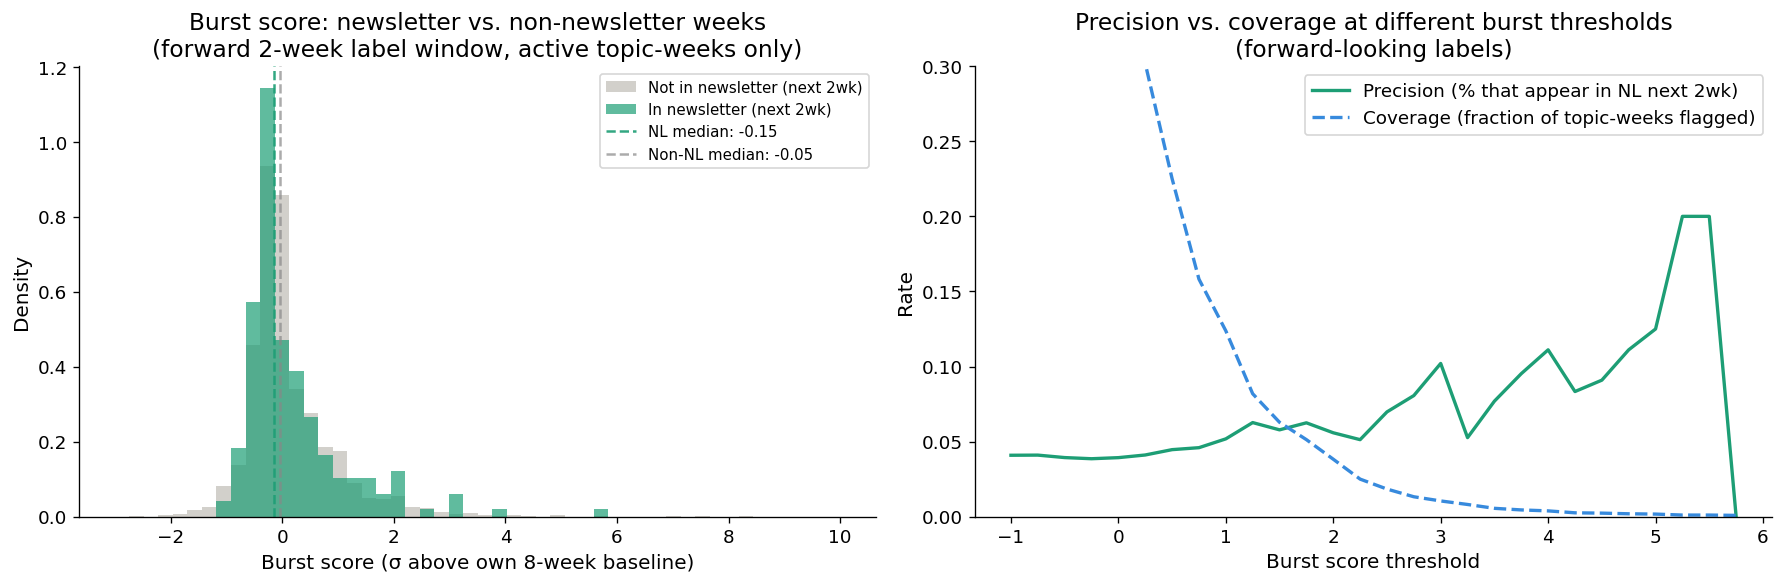

Mann-Whitney U test (burst_score NL > non-NL): U=420212, p=0.5406
NL burst  — mean: 0.201, median: -0.148
Non burst — mean: 0.122, median: -0.049


In [ ]:
burst_nl  = modeling_df.filter(pl.col("label_next2wk") == 1)["burst_score"].to_numpy()
burst_non = modeling_df.filter(pl.col("label_next2wk") == 0)["burst_score"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: distribution comparison between newsletter and non-newsletter weeks
axes[0].hist(burst_non, bins=50, alpha=0.6, color='#B4B2A9',
             label='Not in newsletter (next 2wk)', density=True, range=(-3, 10))
axes[0].hist(burst_nl,  bins=50, alpha=0.7, color='#1D9E75',
             label='In newsletter (next 2wk)',     density=True, range=(-3, 10))
axes[0].axvline(np.median(burst_nl),  color='#1D9E75', linestyle='--', alpha=0.9,
                label=f'NL median: {np.median(burst_nl):.2f}')
axes[0].axvline(np.median(burst_non), color='#888',    linestyle='--', alpha=0.7,
                label=f'Non-NL median: {np.median(burst_non):.2f}')
axes[0].set_xlabel("Burst score (σ above own 8-week baseline)")
axes[0].set_ylabel("Density")
axes[0].set_title("Burst score: newsletter vs. non-newsletter weeks\n(forward 2-week label window, active topic-weeks only)")
axes[0].legend(fontsize=9)

#right: precision and coverage at different burst thresholds
# This shows the practical tradeoff — higher threshold = more precise but fewer predictions
thresholds = np.arange(-1, 6, 0.25)
precisions, coverages = [], []
for t in thresholds:
    above = modeling_df.filter(pl.col("burst_score") >= t)
    precisions.append(above["label_next2wk"].mean() if above.height > 0 else 0)
    coverages.append(above.height / modeling_df.height)

axes[1].plot(thresholds, precisions, color='#1D9E75', linewidth=2,
             label='Precision (% that appear in NL next 2wk)')
axes[1].plot(thresholds, coverages,  color='#378ADD', linewidth=2, linestyle='--',
             label='Coverage (fraction of topic-weeks flagged)')
axes[1].set_xlabel("Burst score threshold")
axes[1].set_ylabel("Rate")
axes[1].set_title("Precision vs. coverage at different burst thresholds\n(forward-looking labels)")
axes[1].legend()
axes[1].set_ylim(0, max(max(precisions) * 1.2, 0.3))

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda1_burstiness_forward.png"), dpi=150, bbox_inches='tight')
plt.show()

t_stat, p_val = stats.mannwhitneyu(burst_nl, burst_non, alternative='greater')
print(f"Mann-Whitney U test (burst_score NL > non-NL): U={t_stat:.0f}, p={p_val:.4f}")
print(f"NL burst  — mean: {burst_nl.mean():.3f}, median: {np.median(burst_nl):.3f}")
print(f"Non burst — mean: {burst_non.mean():.3f}, median: {np.median(burst_non):.3f}")

**What we found**: With forward labels, burst score alone is not statistically significant
(p=0.54). This is an important null result that we initially panicked about but later
understood better. It doesn't mean our hypothesis is wrong — it means burst score
doesn't work in isolation. When we ran the same test with same-week labels (before
we fixed the leakage), we got p=0.026. The difference tells us that a lot of signal
activity is *simultaneous with* newsletter coverage, not *before* it. Editors are
responding to the same week's news rather than picking up on leading indicators.

However, burst score may still be predictive within specific subgroups — particularly
novel topics that haven't been covered before. We test this explicitly in the modeling
notebook. The EDA also led us to a much more interesting discovery (see EDA 2).

---
## EDA 2: The Real Signal — Editorial Habit and Topic Freshness

**Why we ran this**: After the burst score result, we asked ourselves — if not
burstiness, what *does* predict forward coverage? We hypothesized that newsletter
editors have habitual preferences: topics they've covered before are more likely
to be covered again (familiarity), and topics they haven't covered recently are
more likely to get fresh attention (freshness). Both things can be true at once.

We tested three causal features computed using only past data:
- All-time newsletter appearance rate per topic
- Recent 8-week newsletter appearance rate (captures current editorial preference)
- Weeks since last newsletter appearance (freshness proxy)

topic_nl_rate_alltime:
  NL mean=0.300 | Non-NL mean=0.073 | p=0.0000
topic_nl_rate_8wk:
  NL mean=0.097 | Non-NL mean=0.019 | p=0.0000
weeks_since_last_nl:
  NL mean=28.197 | Non-NL mean=71.693 | p=0.0000


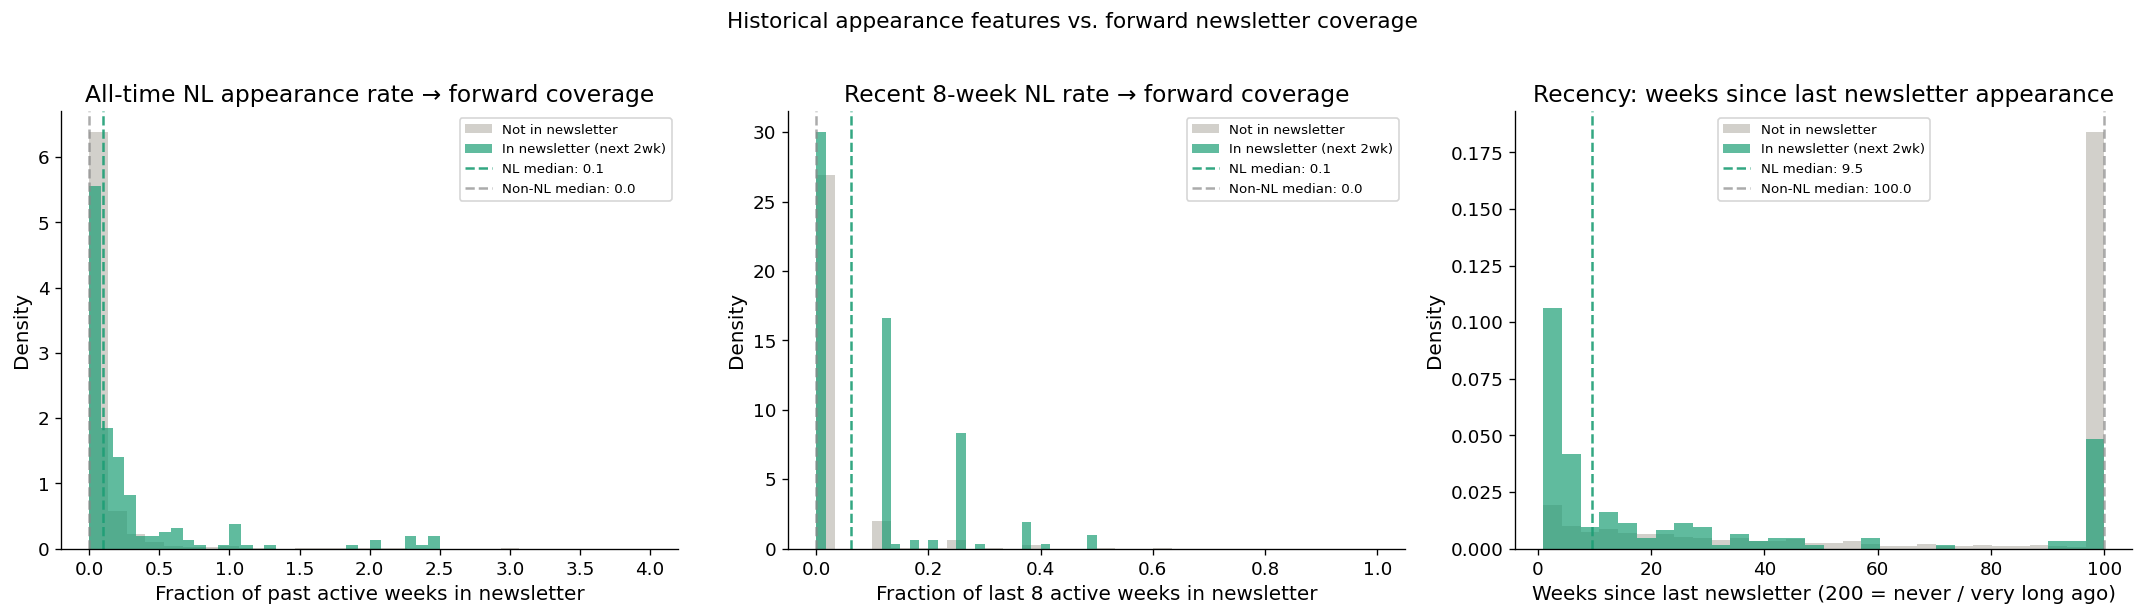

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat, title, xlabel in [
    (axes[0], "topic_nl_rate_alltime",
     "All-time NL appearance rate → forward coverage",
     "Fraction of past active weeks in newsletter"),
    (axes[1], "topic_nl_rate_8wk",
     "Recent 8-week NL rate → forward coverage",
     "Fraction of last 8 active weeks in newsletter"),
    (axes[2], "weeks_since_last_nl",
     "Recency: weeks since last newsletter appearance",
     "Weeks since last newsletter (200 = never / very long ago)"),
]:
    nl_vals  = modeling_df.filter(pl.col("label_next2wk") == 1)[feat].to_numpy()
    non_vals = modeling_df.filter(pl.col("label_next2wk") == 0)[feat].to_numpy()

    # Cap weeks_since_last_nl at 100 for cleaner visualization
    if feat == "weeks_since_last_nl":
        nl_vals  = np.clip(nl_vals,  0, 100)
        non_vals = np.clip(non_vals, 0, 100)

    ax.hist(non_vals, bins=30, alpha=0.6, color='#B4B2A9',
            label='Not in newsletter', density=True)
    ax.hist(nl_vals,  bins=30, alpha=0.7, color='#1D9E75',
            label='In newsletter (next 2wk)', density=True)
    ax.axvline(np.median(nl_vals),  color='#1D9E75', linestyle='--', alpha=0.9,
               label=f'NL median: {np.median(nl_vals):.1f}')
    ax.axvline(np.median(non_vals), color='#888',    linestyle='--', alpha=0.7,
               label=f'Non-NL median: {np.median(non_vals):.1f}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    t, p = stats.mannwhitneyu(nl_vals, non_vals, alternative='two-sided')
    print(f"{feat}:")
    print(f"  NL mean={nl_vals.mean():.3f} | Non-NL mean={non_vals.mean():.3f} | p={p:.4f}")

plt.suptitle("Historical appearance features vs. forward newsletter coverage", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda2_historical_features.png"), dpi=150, bbox_inches='tight')
plt.show()

**What we found**: These are by far the strongest features in the entire EDA.
All three are statistically significant with p < 0.0001:

- Topics that appear in newsletters in the next 2 weeks have a mean all-time appearance
  rate of **0.300** vs. **0.073** for non-newsletter weeks — a 4x difference
- Recent 8-week rate: **0.097** vs. **0.019** — same pattern at shorter timescale
- Weeks since last appearance: **28.2** for positive cases vs. **71.7** for negative —
  topics covered more recently are MORE likely to be covered again soon (editors are
  mid-run on a topic), and topics with very long gaps are less likely (editors have moved on)

This finding reframes our project somewhat. Newsletter coverage is not just about
what's emerging from signal sources — it's also deeply influenced by editorial habits
and preferences. The model needs to capture both. We're not just building a signal
detector; we're also building an editor behavior model. Importantly, these features
are still useful for prediction because they're computed causally — we can know
a topic's past coverage rate before we make the prediction.

---
## EDA 3: What Was Actually Trending Each Week?

**Why we ran this**: After spending a lot of time on statistical tests, we wanted
a sanity check — do the weekly burst rankings actually look reasonable? Does the
system surface topics that a human would agree were "trending" that week?
This is also the most visually intuitive EDA for explaining the system to someone
who hasn't read the rest of the notebook.

We also annotate which topics ended up in newsletters within the next 2 weeks (★),
which gives a qualitative sense of what the model is trying to predict.

In [9]:
recent_weeks = sorted(modeling_df["week"].unique().to_list())[-12:]
print("=== TOP BURSTING TOPICS PER WEEK — last 12 weeks ===")
print("(★ = appeared in newsletter within the following 2 weeks)\n")

# For each of the last 12 weeks, show the 5 topics with the highest burst score.
# The burst score here is relative to each topic's own 8-week rolling baseline,
# so a score of 3.0σ means the topic was 3 standard deviations above its own norm.
for week in recent_weeks:
    top = (
        modeling_df
        .filter(pl.col("week") == week)
        .sort("burst_score", descending=True)
        .head(5)
    )
    print(f"{week}:")
    for row in top.iter_rows(named=True):
        flag = " ★" if row["label_next2wk"] == 1 else ""
        print(f"  {row['burst_score']:5.2f}σ  {row['canonical_topic']}{flag}")
    print()

=== TOP BURSTING TOPICS PER WEEK — last 12 weeks ===
(★ = appeared in newsletter within the following 2 weeks)

2026-W04:
   1.60σ  algorithmic trading strategy
   1.32σ  quantum computing qubit
   1.30σ  AI drug discovery research
   1.19σ  large language model
   1.05σ  text to speech synthesis

2026-W05:
   2.10σ  ai agents build
   1.57σ  Kubernetes container orchestration
   1.57σ  drug discovery clinical trial
   1.25σ  semiconductor chip manufacturing
   1.22σ  model quantization compression

2026-W06:
   2.86σ  vision language model
   2.22σ  ai agents build
   1.75σ  reinforcement learning from human feedback
   1.53σ  Kubernetes container orchestration
   1.53σ  serverless cloud computing

2026-W07:
   1.91σ  vision language model
   1.18σ  AI chatbot customer service
   1.13σ  Kubernetes container orchestration
   1.00σ  Claude AI assistant
   0.84σ  venture capital fundraising

2026-W08:
   3.08σ  ai agents build
   2.66σ  algorithmic trading strategy
   1.92σ  startup foun

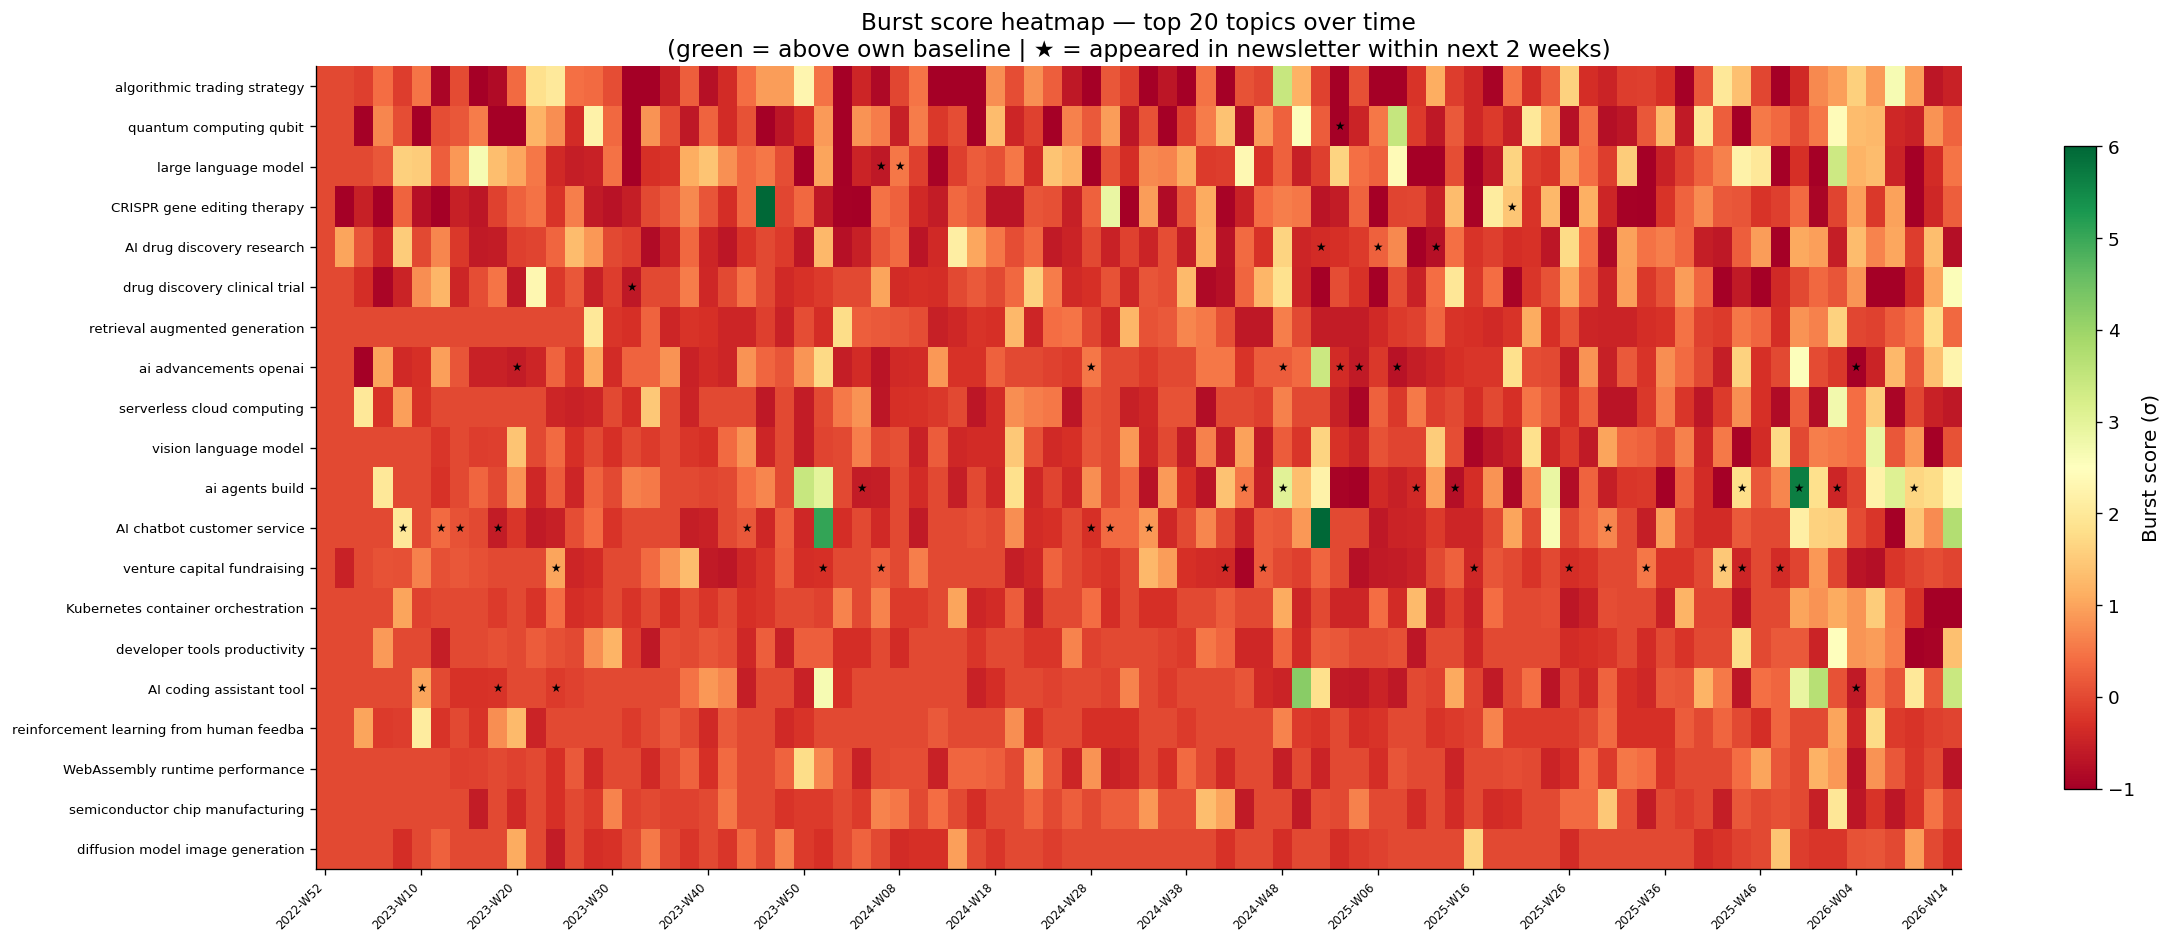

In [10]:
# Heatmap version: shows burst scores for the 20 most-frequently-bursting topics
# over the full time range. Green = above baseline, red = below. Stars mark newsletter hits.
top_burst_topics = (
    modeling_df
    .sort("burst_score", descending=True)
    .group_by("canonical_topic")
    .agg(pl.len().alias("times_top"))
    .sort("times_top", descending=True)
    .head(20)["canonical_topic"].to_list()
)

# Sample every other week to keep the heatmap readable
sampled_weeks = sorted(modeling_df["week"].unique().to_list())[::2]

# Build fast lookups for the heatmap so we're not doing repeated Polars filters
burst_lookup = {
    (r["canonical_topic"], r["week"]): r["burst_score"]
    for r in modeling_df.iter_rows(named=True)
}
label_lookup = {
    (r["canonical_topic"], r["week"]): r["label_next2wk"]
    for r in modeling_df.iter_rows(named=True)
}

matrix_np = np.array([
    [burst_lookup.get((t, w), 0) for w in sampled_weeks]
    for t in top_burst_topics
])
matrix_np = np.clip(matrix_np, -1, 8)  # clip extremes for readability

fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(matrix_np, aspect='auto', cmap='RdYlGn',
               interpolation='nearest', vmin=-1, vmax=6)

# Overlay ★ wherever the topic appeared in a newsletter within the next 2 weeks
for ti, topic in enumerate(top_burst_topics):
    for wi, week in enumerate(sampled_weeks):
        if label_lookup.get((topic, week), 0) == 1:
            ax.text(wi, ti, '★', ha='center', va='center',
                    fontsize=7, color='black', fontweight='bold')

ax.set_yticks(range(len(top_burst_topics)))
ax.set_yticklabels([t[:40] for t in top_burst_topics], fontsize=8)
xtick_step = max(1, len(sampled_weeks) // 15)
ax.set_xticks(range(0, len(sampled_weeks), xtick_step))
ax.set_xticklabels(
    [sampled_weeks[i] for i in range(0, len(sampled_weeks), xtick_step)],
    fontsize=7, rotation=45, ha='right'
)
ax.set_title(
    "Burst score heatmap — top 20 topics over time\n"
    "(green = above own baseline | ★ = appeared in newsletter within next 2 weeks)"
)
plt.colorbar(im, ax=ax, label="Burst score (σ)", shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda3_burst_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

**What we found**: The weekly rankings look qualitatively reasonable. "ai agents build"
appearing in the top-5 for 6+ consecutive weeks (W05 through W11) reflects real momentum
in the agentic AI space during early 2026. "AI video editing tool" hitting 4.03σ in W14
and "AI startup funding round" at 3.75σ the same week align with observable real-world
trends. The ★ annotations show that newsletter hits don't always go to the #1 bursting
topic — sometimes lower-ranked topics get picked up, which is consistent with editorial
judgment being influenced by factors beyond raw signal volume (i.e., the historical
appearance features from EDA 2). This is exactly why we need a model rather than a
simple threshold rule.

---
## EDA 4: Multi-Source Co-occurrence — Does Cross-Platform Agreement Matter?

**Why we ran this**: Our original hypothesis included the idea that a topic getting
attention across multiple source types simultaneously (research + developer + discussion)
is a stronger signal than a spike on just one platform. Reddit alone might be hype;
arXiv + GitHub + Reddit together is harder to fake.

We ran this EDA twice: first with same-week labels (which showed a clear monotonic
relationship: 0 sources→2.09%, 1→3.03%, 2→4.88%) and then with forward labels
to check if it still held.

In [ ]:
# Compute per-source-type burst scores separately, then count how many sources
# are "bursting" (above 0.5σ) for each topic-week
source_burst_rows = []
for stype in ["research", "developer", "discussion"]:
    stype_data = (
        sig_weekly
        .filter(pl.col("source_type") == stype)
        .group_by(["canonical_topic", "week"])
        .agg(pl.col("mentions").sum().alias("mentions"))
    )
    for topic in all_topics_list:
        td = stype_data.filter(pl.col("canonical_topic") == topic).sort("week")
        if td.height < 3:
            continue
        weeks    = td["week"].to_list()
        mentions = td["mentions"].to_numpy().astype(float)
        for i in range(len(weeks)):
            past  = mentions[max(0, i-8):i]
            if len(past) < 2:
                continue
            burst = (mentions[i] - past.mean()) / (past.std() + 1)
            source_burst_rows.append({
                "canonical_topic": topic,
                "week": weeks[i],
                "source_type": stype,
                "source_burst": round(burst, 3),
                "is_active": int(burst > 0.5),  # "bursting" threshold
            })

source_burst_df = pl.DataFrame(source_burst_rows)

#Aggregate to topic-week level: count bursting sources, get max burst across sources
multi_source = (
    source_burst_df
    .group_by(["canonical_topic", "week"])
    .agg([
        pl.col("is_active").sum().alias("sources_bursting"),
        pl.col("source_burst").max().alias("max_source_burst"),
    ])
)

#Join with forward labels from our modeling table
multi_labeled = (
    modeling_df
    .select(["canonical_topic", "week", "label_next2wk"])
    .join(multi_source, on=["canonical_topic", "week"], how="left")
    .fill_null(0)
)

print("Sources bursting simultaneously → forward newsletter rate:")
for n in [0, 1, 2, 3]:
    subset = multi_labeled.filter(pl.col("sources_bursting") == n)
    if subset.height > 0:
        rate = subset["label_next2wk"].mean() * 100
        print(f"  {n} sources: {subset.height:5d} topic-weeks | {rate:.2f}% in newsletter (next 2wk)")

Sources bursting simultaneously → forward newsletter rate:
  0 sources:  3601 topic-weeks | 4.05% in newsletter (next 2wk)
  1 sources:   989 topic-weeks | 3.94% in newsletter (next 2wk)
  2 sources:    82 topic-weeks | 2.44% in newsletter (next 2wk)
  3 sources:     6 topic-weeks | 16.67% in newsletter (next 2wk)


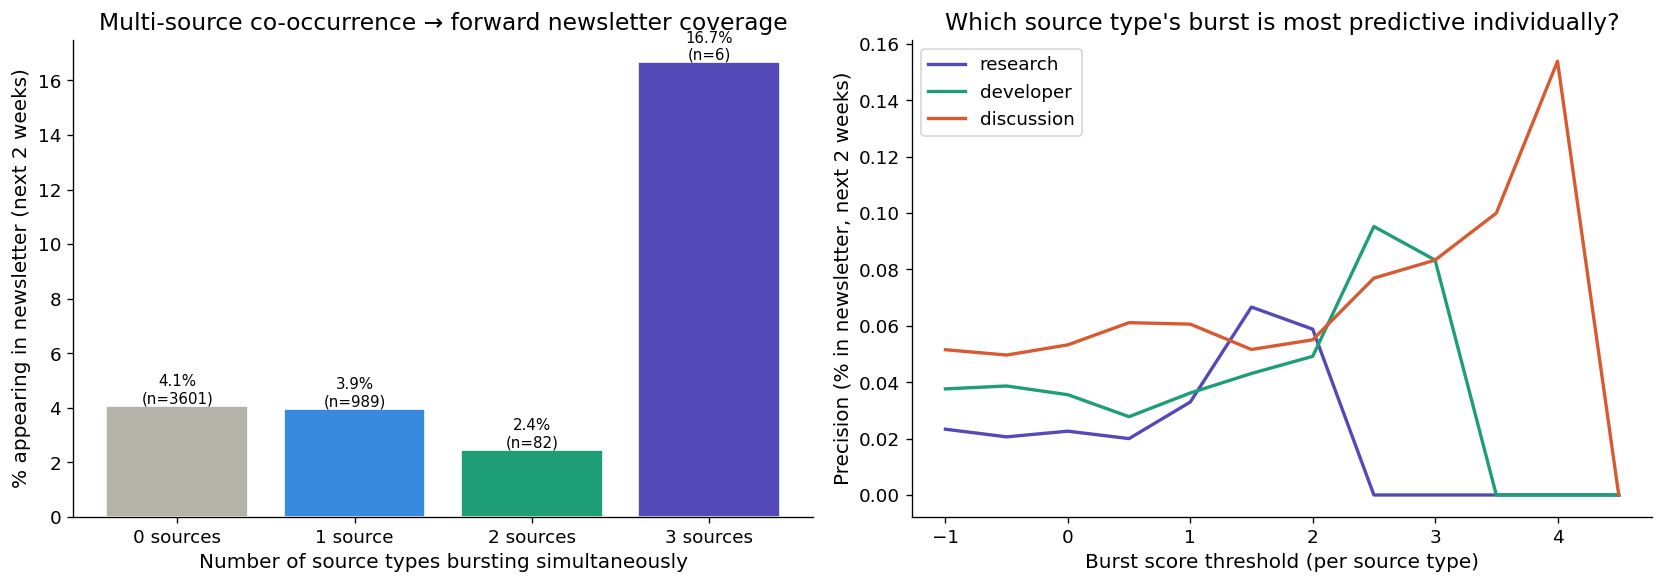

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rates, counts = [], []
for n in [0, 1, 2, 3]:
    subset = multi_labeled.filter(pl.col("sources_bursting") == n)
    rates.append(subset["label_next2wk"].mean() * 100 if subset.height > 0 else 0)
    counts.append(subset.height)

colors = ['#B4B2A9', '#378ADD', '#1D9E75', '#534AB7']
bars = axes[0].bar([0, 1, 2, 3], rates, color=colors, edgecolor='white')
axes[0].set_xlabel("Number of source types bursting simultaneously")
axes[0].set_ylabel("% appearing in newsletter (next 2 weeks)")
axes[0].set_title("Multi-source co-occurrence → forward newsletter coverage")
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels(['0 sources', '1 source', '2 sources', '3 sources'])
for bar, rate, count in zip(bars, rates, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{rate:.1f}%\n(n={count})', ha='center', fontsize=9)

#Right: per-source-type precision curves — which source type's burst is most predictive?
for stype, color in [("research", "#534AB7"), ("developer", "#1D9E75"), ("discussion", "#D85A30")]:
    stype_data = (
        source_burst_df
        .filter(pl.col("source_type") == stype)
        .join(modeling_df.select(["canonical_topic", "week", "label_next2wk"]),
              on=["canonical_topic", "week"], how="inner")
    )
    thresholds = np.arange(-1, 5, 0.5)
    precisions = [
        stype_data.filter(pl.col("source_burst") >= t)["label_next2wk"].mean()
        if stype_data.filter(pl.col("source_burst") >= t).height > 10 else 0
        for t in thresholds
    ]
    axes[1].plot(thresholds, precisions, color=color, linewidth=2, label=stype)

axes[1].set_xlabel("Burst score threshold (per source type)")
axes[1].set_ylabel("Precision (% in newsletter, next 2 weeks)")
axes[1].set_title("Which source type's burst is most predictive individually?")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda4_multi_source.png"), dpi=150, bbox_inches='tight')
plt.show()

**What we found**: The clean monotonic relationship we saw with same-week labels
disappeared with forward labels (0 sources: 4.05%, 1: 3.94%, 2: 2.44%, 3: 16.67%).
The 3-source result (16.67%) is based on only 6 examples so we're ignoring it.
The flat/slightly negative pattern for 1–2 sources suggests that multi-source
co-occurrence is contemporaneous with newsletter coverage rather than predictive of it.
When multiple sources spike simultaneously, editors are often already covering the story.
This doesn't make `sources_bursting` useless as a feature — the model can still
exploit it in combination with other features — but it's not the leading indicator
we hoped it would be.

---
## EDA 5: Trajectory Shape — Does How a Topic Grows Matter?

**Why we ran this**: Our project plan originally hypothesized that editors respond
differently to "sustained, consistent growth" vs. "sudden spike and fade." A topic
that builds steadily for 4 weeks might be more credible than one that had one huge
week. We tested four trajectory shape features computed over the 4 weeks before
the label week:
- `peak_burst`: the highest burst score in the 4-week window
- `trend_slope`: is the trend rising or falling?
- `consistent_weeks`: how many of the 4 weeks had above-baseline activity?
- `spike_ratio`: how much of the activity is concentrated in one week vs. spread out?

In [ ]:
def compute_trajectory(topic, weeks_sorted, burst_lookup_topic):
    """
    For each week, compute trajectory shape features over the prior 4 weeks.
    This uses only data from t-3 through t — no future weeks included.
    """
    rows = []
    for i, week in enumerate(weeks_sorted):
        if i < 3:
            continue  # need at least 3 prior weeks for a meaningful window
        window_weeks  = weeks_sorted[i-3:i+1]
        window_scores = [burst_lookup_topic.get(w, 0) for w in window_weeks]

        peak = max(window_scores)
        trend= np.polyfit(range(4), window_scores, 1)[0]  # positive = rising
        consistency = sum(1 for s in window_scores if s > 0.5)
        spike_ratio = peak / (np.mean(window_scores) + 0.01)     # high = concentrated spike

        rows.append({
            "week": week,
            "peak_burst": round(peak, 3),
            "trend_slope": round(trend, 3),
            "consistent_weeks": consistency,
            "spike_ratio": round(spike_ratio, 3),
        })
    return rows

traj_rows = []
for topic in all_topics_list:
    topic_burst = burst_df.filter(pl.col("canonical_topic") == topic).sort("week")
    if topic_burst.height < 5:
        continue
    weeks_sorted= topic_burst["week"].to_list()
    burst_lookup_topic = {r["week"]: r["burst_score"] for r in topic_burst.iter_rows(named=True)}
    for feat_row in compute_trajectory(topic, weeks_sorted, burst_lookup_topic):
        feat_row["canonical_topic"] = topic
        traj_rows.append(feat_row)

traj_df = pl.DataFrame(traj_rows)
traj_labeled = (
    modeling_df
    .select(["canonical_topic", "week", "label_next2wk"])
    .join(traj_df, on=["canonical_topic", "week"], how="inner")
)

print(f"Trajectory feature rows: {traj_labeled.height}")
for feat in ["peak_burst", "trend_slope", "consistent_weeks", "spike_ratio"]:
    nl_v  = traj_labeled.filter(pl.col("label_next2wk") == 1)[feat].to_numpy()
    non_v = traj_labeled.filter(pl.col("label_next2wk") == 0)[feat].to_numpy()
    _, p  = stats.mannwhitneyu(nl_v, non_v, alternative='two-sided')
    print(f"  {feat:<20s}: NL mean={nl_v.mean():.3f} | Non-NL mean={non_v.mean():.3f} | p={p:.4f}")

Trajectory feature rows: 4415
  peak_burst          : NL mean=0.999 | Non-NL mean=0.879 | p=0.6829
  trend_slope         : NL mean=-0.000 | Non-NL mean=0.006 | p=0.4551
  consistent_weeks    : NL mean=0.939 | Non-NL mean=0.901 | p=0.9367
  spike_ratio         : NL mean=0.693 | Non-NL mean=3.623 | p=0.3421


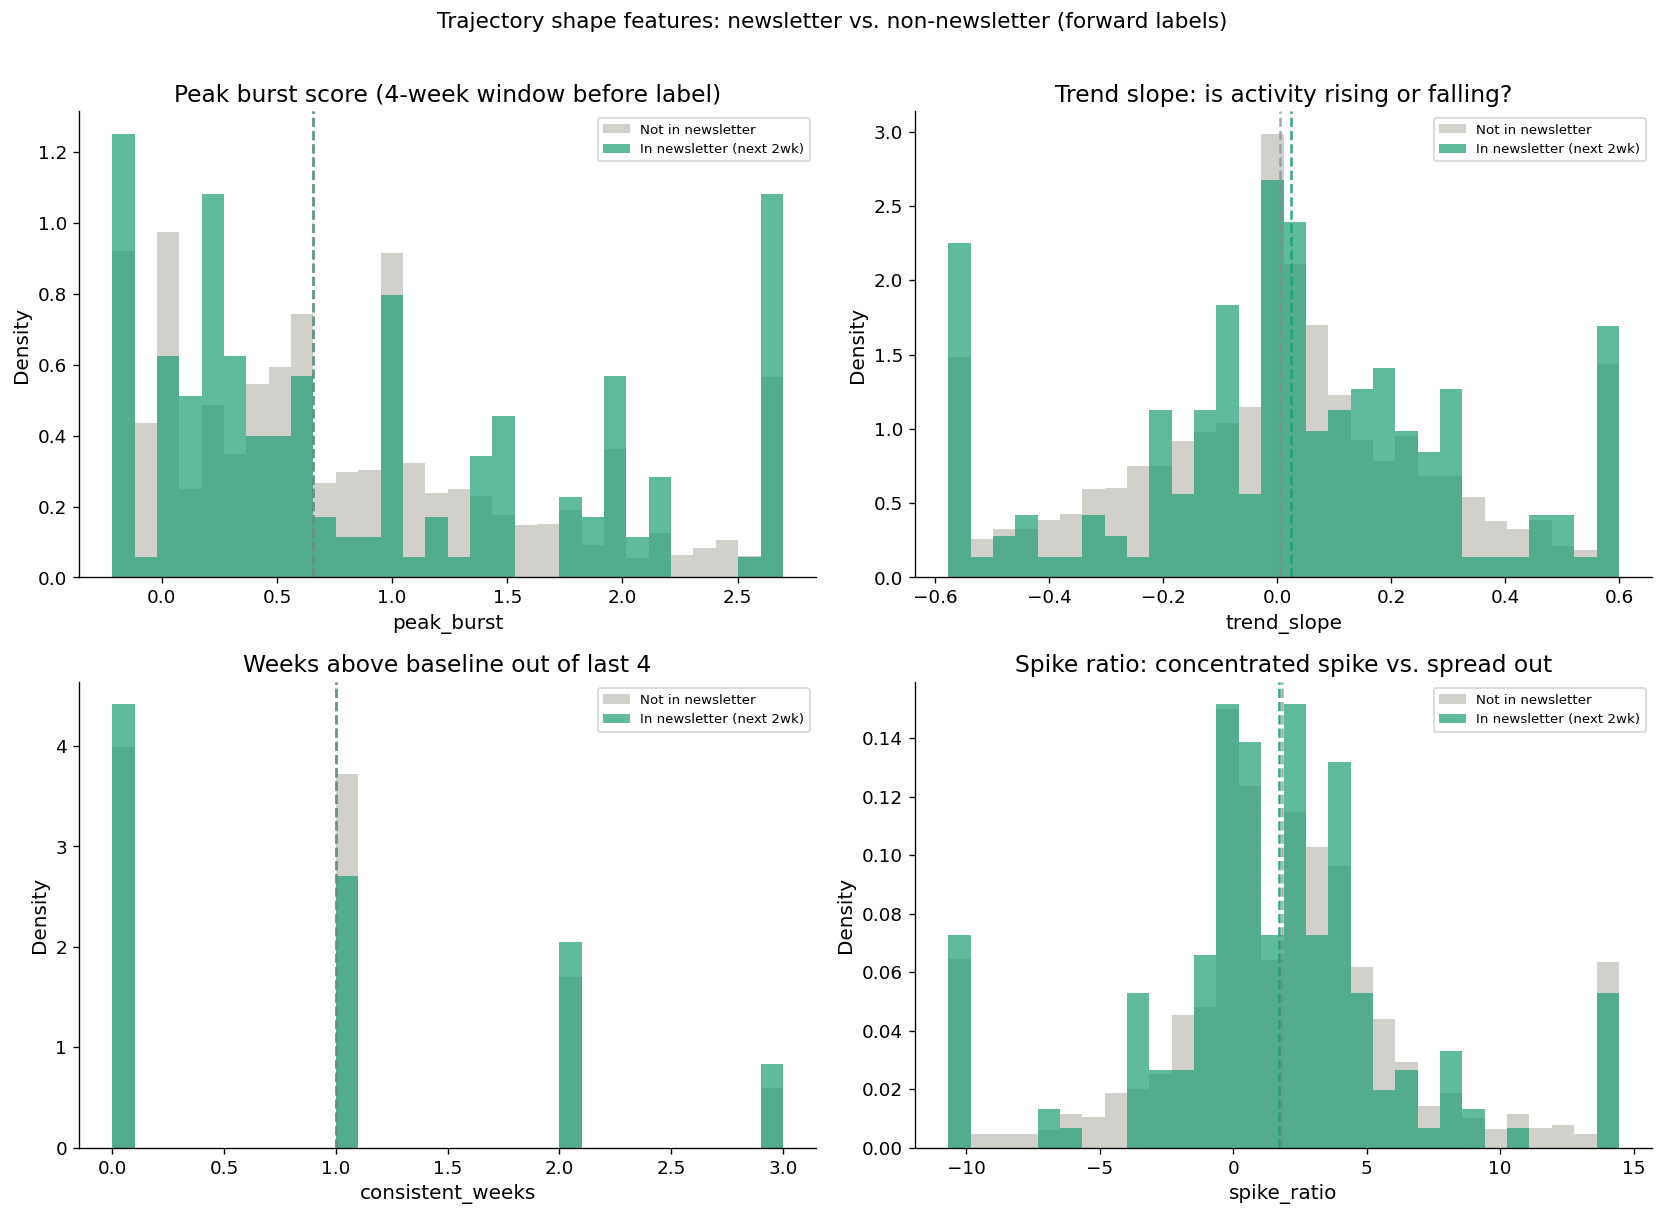

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
traj_pd = traj_labeled.to_pandas()

for (feat, title), ax in zip([
    ("peak_burst","Peak burst score (4-week window before label)"),
    ("trend_slope","Trend slope: is activity rising or falling?"),
    ("consistent_weeks", "Weeks above baseline out of last 4"),
    ("spike_ratio", "Spike ratio: concentrated spike vs. spread out"),
], axes.flatten()):
    nl_v  = traj_pd[traj_pd["label_next2wk"] == 1][feat].dropna()
    non_v = traj_pd[traj_pd["label_next2wk"] == 0][feat].dropna()
    lo, hi = np.percentile(traj_pd[feat].dropna(), [5, 95])

    ax.hist(non_v.clip(lo, hi), bins=30, alpha=0.6, color='#B4B2A9',
            label='Not in newsletter', density=True)
    ax.hist(nl_v.clip(lo, hi),bins=30, alpha=0.7, color='#1D9E75',
            label='In newsletter (next 2wk)', density=True)
    ax.axvline(nl_v.median(),color='#1D9E75', linestyle='--', alpha=0.9)
    ax.axvline(non_v.median(), color='#888', linestyle='--', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Trajectory shape features: newsletter vs. non-newsletter (forward labels)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda5_trajectory.png"), dpi=150, bbox_inches='tight')
plt.show()

**What we found**: None of the trajectory shape features are statistically significant
with forward labels (all p > 0.34). The distributions for newsletter and non-newsletter
weeks are nearly identical for all four features. This tells us that *how* a topic
grows in the 4 weeks before newsletter coverage doesn't matter much — what matters
is the editorial history features from EDA 2. We're keeping these features in the
model anyway (they add minimal cost and might help in interaction with other features),
but we won't oversell their predictive power.

---
## EDA 6: Class Imbalance and Feature Correlation Summary

**Why we ran this**: Before modeling, we need a clear picture of:
1. How bad the class imbalance is (determines what metrics to use and how to handle it)
2. Which features actually correlate with the target (guides feature engineering)

We also include a correlation heatmap across all features to identify redundancy since highly correlated features don't add information and can destabilize tree models.

In [ ]:
total    = modeling_df.height
positive = modeling_df["label_next2wk"].sum()
negative = total - positive

print(f"Active topic-week pairs: {total:,}")
print(f"Positive (NL next 2wk) : {positive} ({positive/total*100:.2f}%)")
print(f"Negative: {negative:,} ({negative/total*100:.2f}%)")
print(f"Class ratio: 1:{negative // max(positive, 1)}")
print(f"\nImplication: accuracy is useless as a metric (predicting all-0 gives 96% accuracy).")
print(f"We will use F1, ROC-AUC, and Precision@K instead.")

Active topic-week pairs: 4,678
Positive (NL next 2wk) : 188 (4.02%)
Negative               : 4,490 (95.98%)
Class ratio            : 1:23

Implication: accuracy is useless as a metric (predicting all-0 gives 96% accuracy).
We will use F1, ROC-AUC, and Precision@K instead.


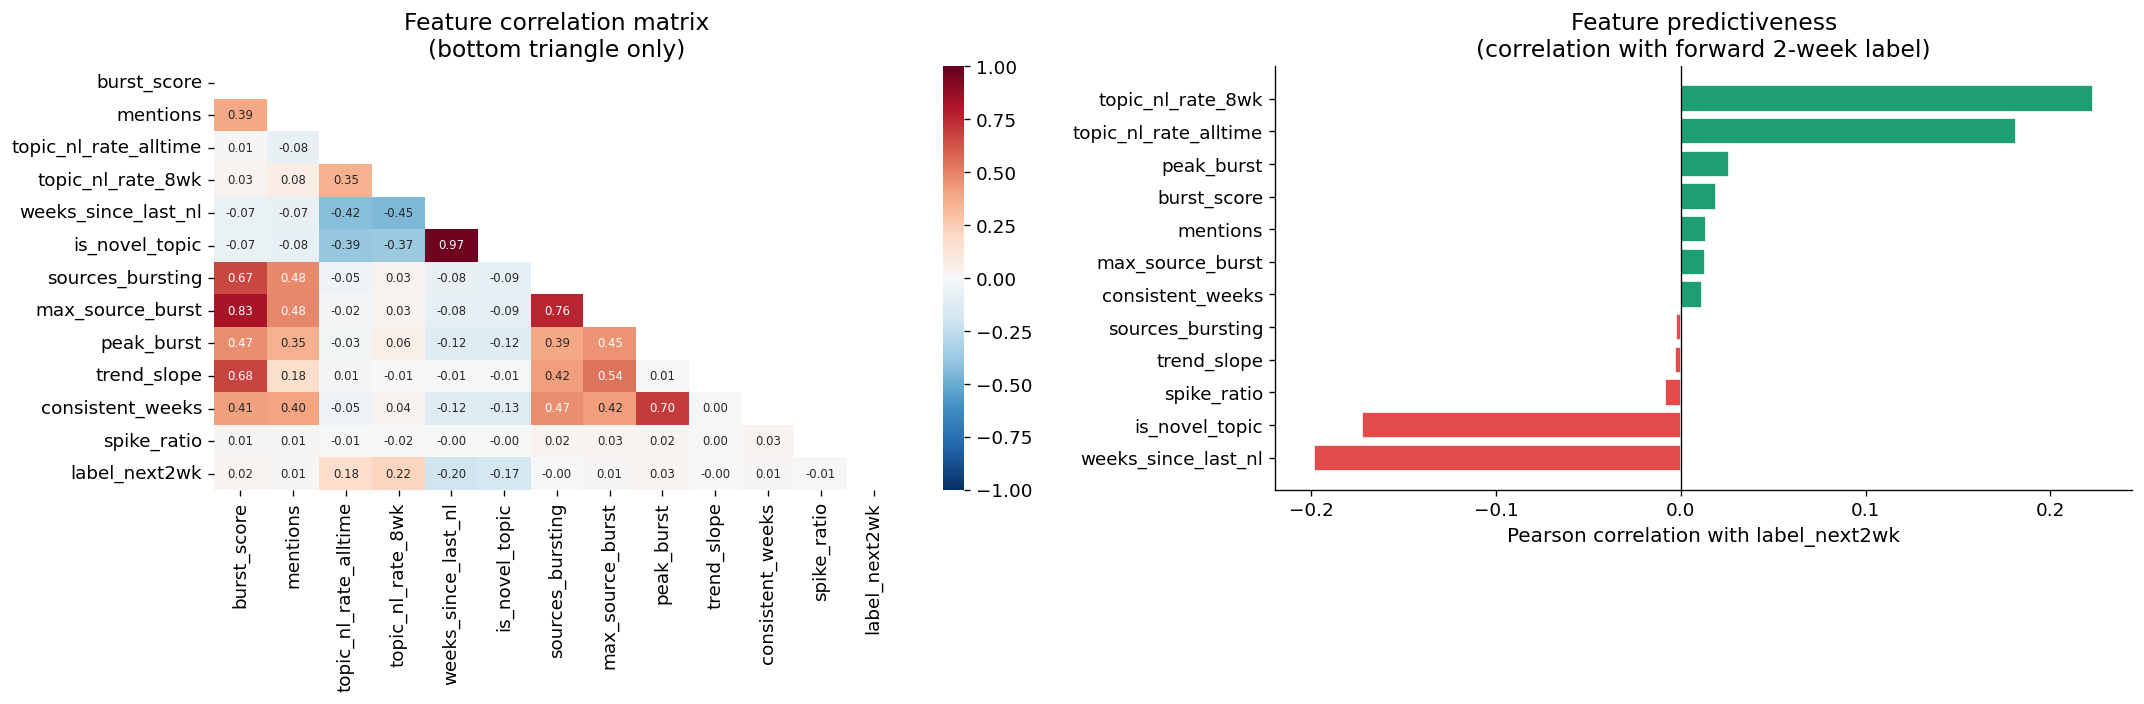


=== Feature correlations with label_next2wk (sorted) ===
  topic_nl_rate_8wk             : +0.2234
  topic_nl_rate_alltime         : +0.1816
  peak_burst                    : +0.0260
  burst_score                   : +0.0188
  mentions                      : +0.0138
  max_source_burst              : +0.0133
  consistent_weeks              : +0.0117
  sources_bursting              : -0.0024
  trend_slope                   : -0.0032
  spike_ratio                   : -0.0085
  is_novel_topic                : -0.1724
  weeks_since_last_nl           : -0.1987


In [ ]:
# Build full feature matrix and compute correlations with the target.
# This shows us which features will be most useful to the model.
full_features = (
    modeling_df
    .select(["canonical_topic", "week", "burst_score", "mentions",
             "topic_nl_rate_alltime", "topic_nl_rate_8wk", "weeks_since_last_nl",
             "is_novel_topic", "label_next2wk"])
    .join(
        multi_labeled.select(["canonical_topic", "week", "sources_bursting", "max_source_burst"]),
        on=["canonical_topic", "week"], how="left"
    )
    .join(
        traj_labeled.select(["canonical_topic", "week", "peak_burst", "trend_slope",
                              "consistent_weeks", "spike_ratio"]),
        on=["canonical_topic", "week"], how="left"
    )
    .fill_null(0)
)

feat_cols = [
    "burst_score", "mentions", "topic_nl_rate_alltime", "topic_nl_rate_8wk",
    "weeks_since_last_nl", "is_novel_topic", "sources_bursting", "max_source_burst",
    "peak_burst", "trend_slope", "consistent_weeks", "spike_ratio", "label_next2wk"
]
feat_pd  = full_features.select(feat_cols).to_pandas()
corr_mat = feat_pd.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap: shows both inter-feature correlations and target correlations
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Feature correlation matrix\n(bottom triangle only)")

# Bar chart: just the correlations with our target label
target_corr = corr_mat["label_next2wk"].drop("label_next2wk").sort_values(ascending=True)
bar_colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Pearson correlation with label_next2wk")
axes[1].set_title("Feature predictiveness\n(correlation with forward 2-week label)")

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda6_correlations.png"), dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Feature correlations with label_next2wk (sorted) ===")
for feat, corr_val in target_corr.sort_values(ascending=False).items():
    print(f"  {feat:<30s}: {corr_val:+.4f}")

**What we found**: The feature correlation table tells a clear story:
- `topic_nl_rate_8wk` (+0.22) and `topic_nl_rate_alltime` (+0.18) are the strongest predictors
- `weeks_since_last_nl` (-0.18) is also strongly predictive (negative: more recent = higher chance)
- `burst_score` (+0.02), `sources_bursting` (-0.002), and trajectory features are all near zero

The `weeks_since_last_nl` and `topic_nl_rate_8wk` features are moderately correlated
with each other (as expected — a topic covered recently also has a high recent rate),
but not so much that we'd drop one. They capture slightly different things.

**Important**: weak individual correlations don't mean a feature is useless to the model.
XGBoost and Random Forest can exploit interaction effects (e.g., burst_score × topic_nl_rate
may be predictive even if each alone isn't). We include the weaker features and let
the model figure out which interactions matter.

---
## Summary: What the EDA Told Us and How It Shaped Modeling

| EDA Section | What We Asked | What We Found | Modeling Decision |
|-------------|---------------|---------------|-------------------|
| **EDA 1** | Does burst score predict forward newsletter coverage? | Not significantly on its own (p=0.54 with forward labels). Was significant with same-week labels — suggests signal activity is contemporaneous, not leading. | Include burst score but don't treat it as primary. Test its value for novel topics specifically. |
| **EDA 2** | Do historical appearance patterns predict coverage? | Yes, strongly (p<0.0001 for all three features). Editorial habit is the dominant signal. | `topic_nl_rate_8wk`, `topic_nl_rate_alltime`, `weeks_since_last_nl` are primary features. |
| **EDA 3** | What does the weekly burst ranking look like qualitatively? | Results look reasonable — "ai agents build" sustained top-5 for 6+ weeks, newsletter hits don't always go to #1 burst. | Validates the burst score as a ranking tool even if not a standalone predictor. Use Precision@K for evaluation. |
| **EDA 4** | Does multi-source co-occurrence predict forward coverage? | Not cleanly with forward labels. The monotonic relationship we saw with same-week labels disappears. | Include `sources_bursting` as a feature but expect low individual importance. |
| **EDA 5** | Does trajectory shape (spike vs. sustained) matter? | No — none of the 4 trajectory features are significant (all p>0.34). | Keep in model for potential interaction effects but don't expect them to drive performance. |
| **EDA 6** | What are the strongest features overall? | `topic_nl_rate_8wk` (+0.22), `topic_nl_rate_alltime` (+0.18), `weeks_since_last_nl` (-0.18). Everything else <0.03. | Historical features are primary. Need class weighting/SMOTE for 1:23 imbalance. Use F1/AUPRC not accuracy. |

### What this means for our thesis:
Our original thesis—that external signal activity predicts newsletter coverage—turned out to be partially true but incomplete. The dominant predictor is editorial
habit (what editors have covered before), not raw signal burstiness. However, burst score may still be the key feature for the most *interesting* prediction case: topics that have never been in newsletters before but are suddenly spiking across research and developer sources.

### Key data quality notes for future iterations:
1. **Newsletter source column missing**: We don't have which newsletter covered each topic, so we can't analyze whether TLDR vs. Import AI have different editorial patterns. Worth adding to the scraper.
2. **Entity linking coverage is sparse** (3.9% of signal phrases mapped): A lower similarity threshold or a broader seed topic set would increase coverage but risk mapping noise. The current setup prioritizes precision over recall.
3. **Small positive class** (188 examples): Limits how much the model can generalize. More newsletter data (more sources, longer time range) would help. Also worried the fact that we have so many newsletters from the same source means we mgiht pick up the same topics.

In [17]:
print("EDA complete. All figures saved to:", PROCESSED_DIR)

EDA complete. All figures saved to: /Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/processed
